In [5]:
# ============================================================
# IBM EMPLOYEE ATTRITION PREDICTION
# Goal: Predict if an employee will leave + find key factors
# ============================================================

# ── 1. Load Dataset ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

# ── Load the Excel file ──────────────────────────────────────
df = pd.read_excel('/content/drive/MyDrive/IBMEmployee_data.xlsx')
print("Shape:", df.shape)
print(df.head(10))

Shape: (1470, 27)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education  EnvironmentSatisfaction  Gender  \
0                 1          2                        2  Female   
1                 8          1   


── Dataset Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EnvironmentSatisfaction   1470 non-null   int64 
 8   Gender                    1470 non-null   object
 9   JobInvolvement            1470 non-null   int64 
 10  JobLevel                  1470 non-null   int64 
 11  JobRole                   1470 non-null   object
 12  JobSatisfaction           1470 non-null   int64 
 13  MaritalStatus             1470 non-null   object
 14  NumC

/tmp/ipykernel_2738/149283852.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Set2')


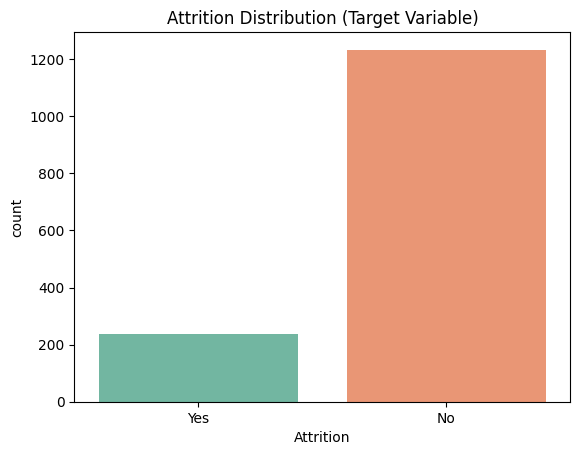

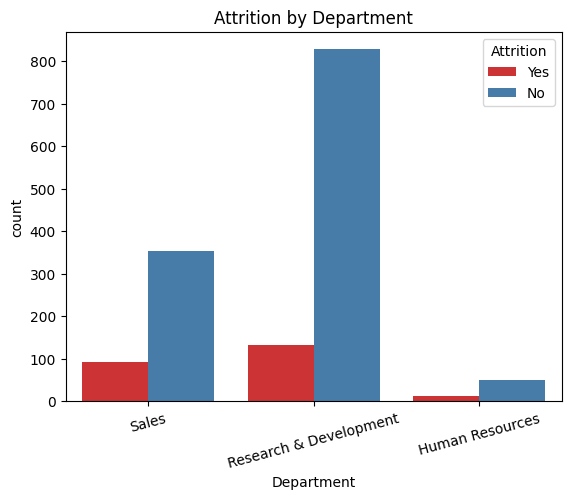

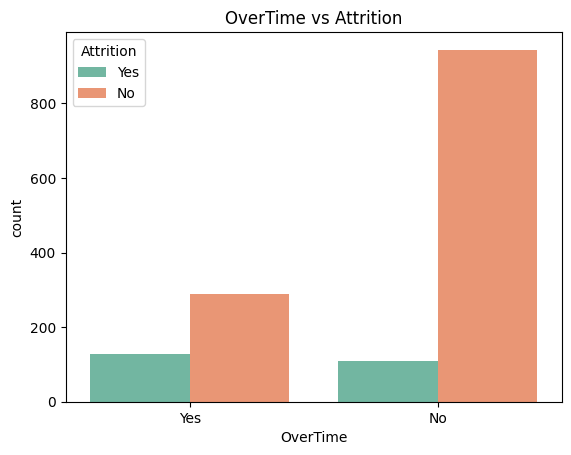

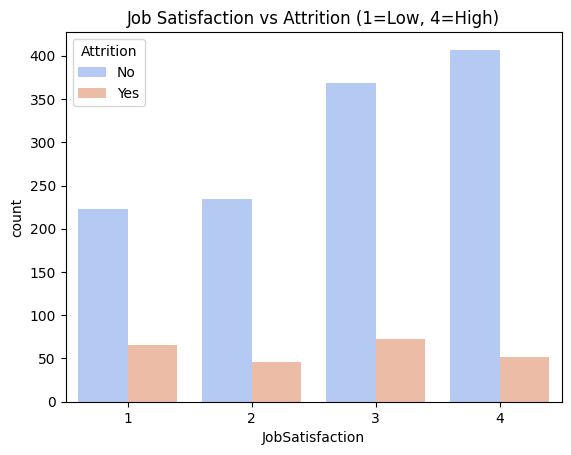

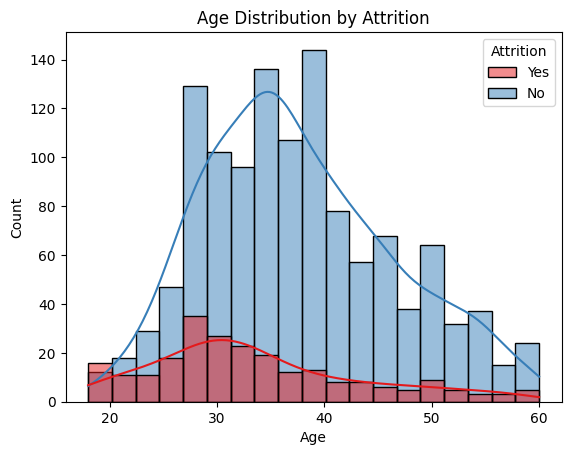

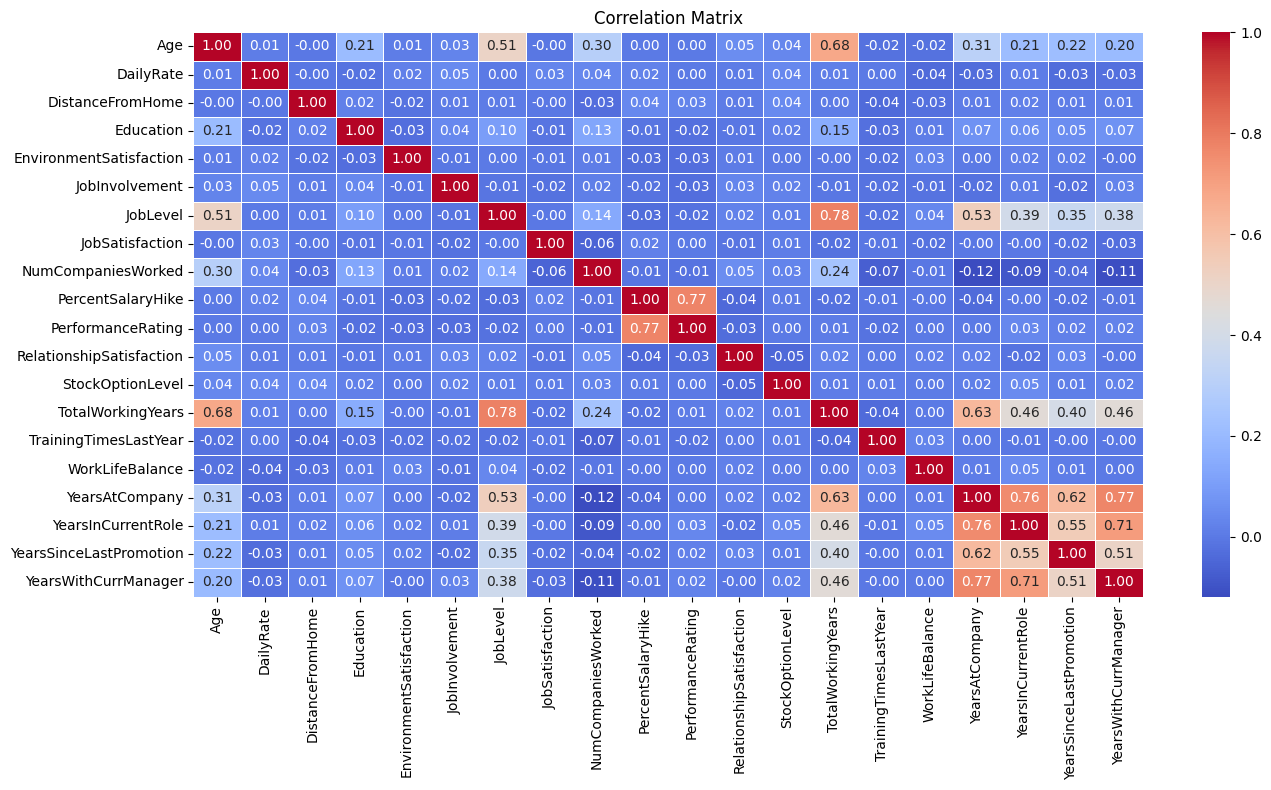

In [6]:
# ── 2. Exploratory Data Analysis (EDA) ──────────────────────
print("\n── Dataset Info ──")
print(df.info())
print("\n── Statistical Summary ──")
print(df.describe())

# Attrition distribution (our target)
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title("Attrition Distribution (Target Variable)")
plt.show()

# Attrition by Department
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set1')
plt.title("Attrition by Department")
plt.xticks(rotation=15)
plt.show()

# Attrition by OverTime
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set2')
plt.title("OverTime vs Attrition")
plt.show()

# Attrition by JobSatisfaction
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, palette='coolwarm')
plt.title("Job Satisfaction vs Attrition (1=Low, 4=High)")
plt.show()

# Age distribution by Attrition
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, palette='Set1')
plt.title("Age Distribution by Attrition")
plt.show()

# Correlation heatmap (numeric columns only)
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [7]:
# ── 3. Data Cleaning & Feature Engineering ───────────────────
# Drop columns with no variance (IBM dataset has a few constant columns)
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'], errors='ignore', inplace=True)

# Drop ID column (not predictive)
df.drop(columns=['EmployeeNumber'], errors='ignore', inplace=True)

# Encode target variable
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Feature engineering
df['TenureRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['PromotionGap'] = df['YearsSinceLastPromotion'] - df['YearsInCurrentRole']

# Label-encode all remaining categorical columns
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("\nEncoding categorical columns:", cat_cols)
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nMissing values after cleaning:")
print(df.isnull().sum().sum(), "total missing values")


Encoding categorical columns: ['BusinessTravel', 'Department', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Missing values after cleaning:
0 total missing values


In [8]:
# ── 4. Define Features & Target ──────────────────────────────
X = df.drop('Attrition', axis=1)
y = df['Attrition']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining samples: {len(X_train)} | Test samples: {len(X_test)}")


Training samples: 1176 | Test samples: 294



── Logistic Regression ──
Accuracy: 0.8877551020408163
              precision    recall  f1-score   support

        Stay       0.90      0.98      0.94       247
       Leave       0.79      0.40      0.54        47

    accuracy                           0.89       294
   macro avg       0.84      0.69      0.74       294
weighted avg       0.88      0.89      0.87       294



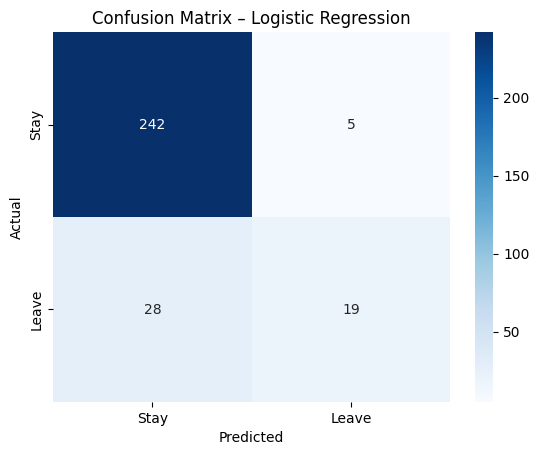

In [9]:
# ── 5. Logistic Regression ───────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("\n── Logistic Regression ──")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=['Stay', 'Leave']))

# Confusion Matrix – LR
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.title("Confusion Matrix – Logistic Regression")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()



── Decision Tree ──
Accuracy: 0.8129251700680272
              precision    recall  f1-score   support

        Stay       0.87      0.92      0.89       247
       Leave       0.38      0.26      0.30        47

    accuracy                           0.81       294
   macro avg       0.62      0.59      0.60       294
weighted avg       0.79      0.81      0.80       294



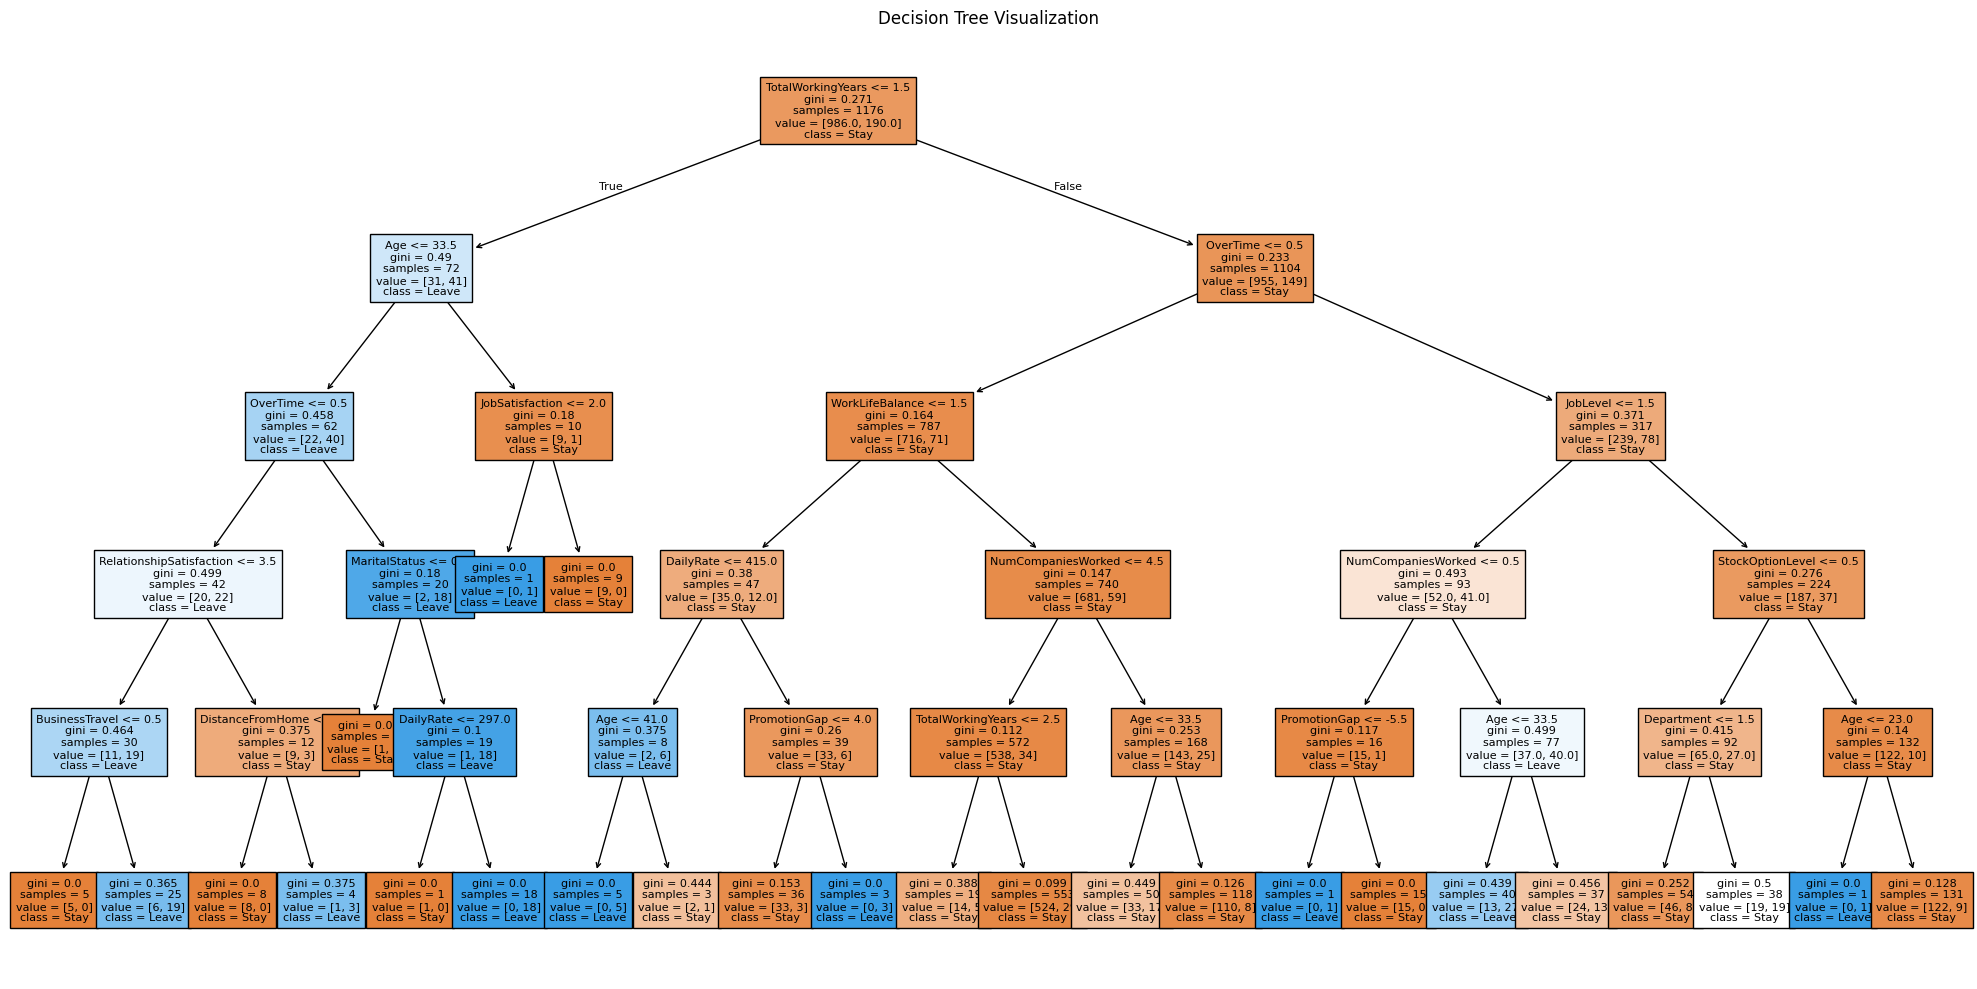

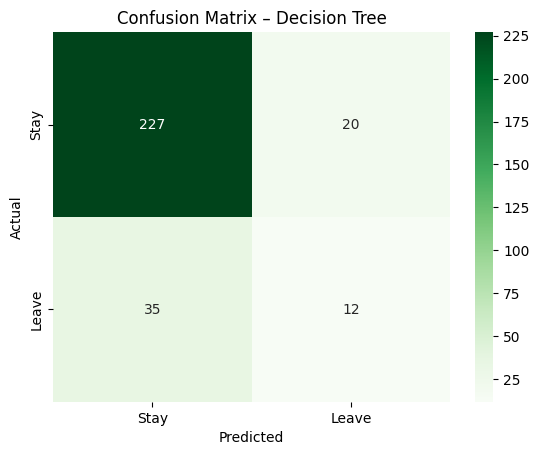

In [10]:
# ── 6. Decision Tree ─────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("\n── Decision Tree ──")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=['Stay', 'Leave']))

# Visualize Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns.tolist(),
          class_names=['Stay', 'Leave'], filled=True, fontsize=8)
plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

# Confusion Matrix – DT
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
plt.title("Confusion Matrix – Decision Tree")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

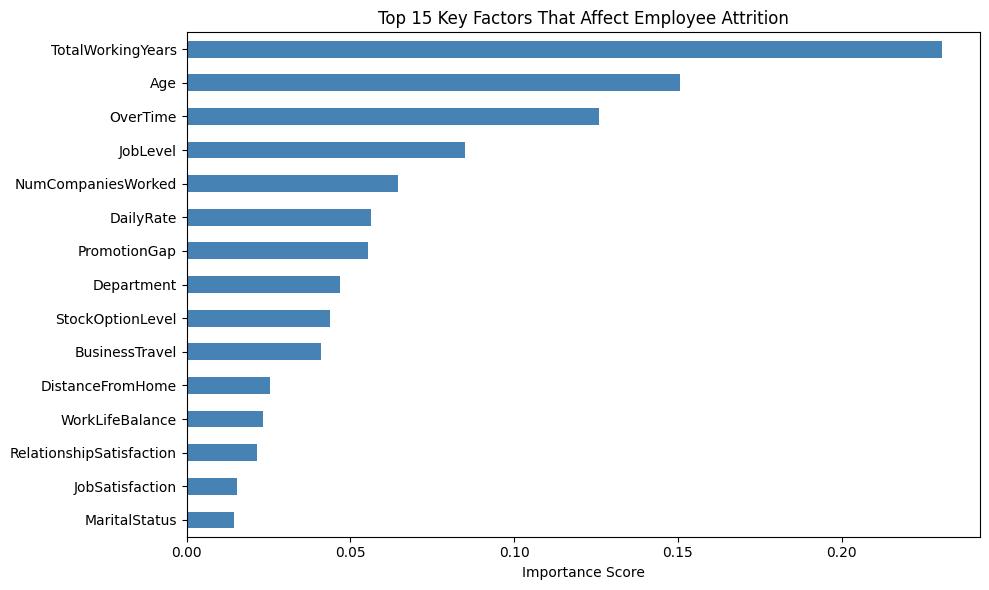


── Top 10 Attrition Factors ──
TotalWorkingYears     0.230748
Age                   0.150750
OverTime              0.125878
JobLevel              0.084895
NumCompaniesWorked    0.064653
DailyRate             0.056205
PromotionGap          0.055488
Department            0.046936
StockOptionLevel      0.043682
BusinessTravel        0.040908
dtype: float64


In [11]:
# ── 7. Feature Importance (Key Attrition Factors) ────────────
feat_imp = pd.Series(dt.feature_importances_, index=X.columns)
top15 = feat_imp.nlargest(15)

plt.figure(figsize=(10, 6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 15 Key Factors That Affect Employee Attrition")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\n── Top 10 Attrition Factors ──")
print(feat_imp.nlargest(10))

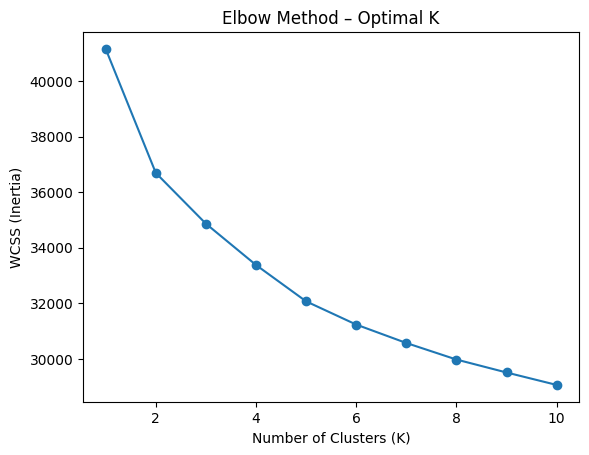

In [12]:
# ── 8. Clustering (Employee Segments) ────────────────────────
X_scaled = scaler.fit_transform(X)

# Elbow Method to find best K
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method – Optimal K")
plt.show()

# K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3)
df['HC_Cluster'] = hc.fit_predict(X_scaled)

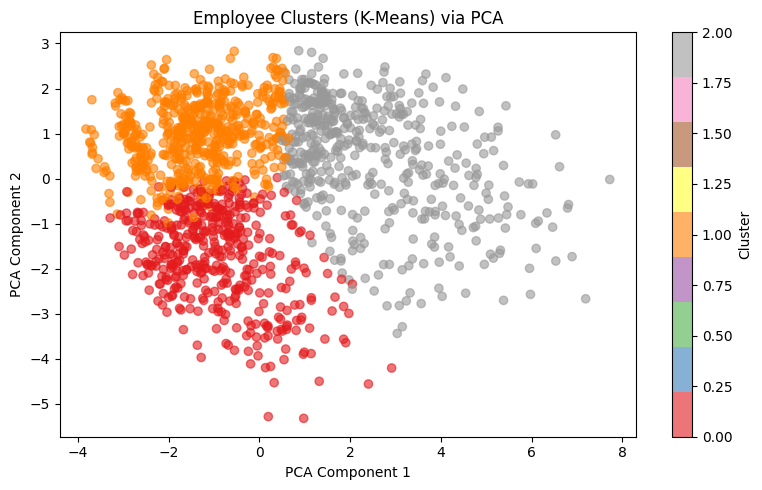


PCA Explained Variance: 24.0%


In [13]:
# ── 9. PCA Visualization ─────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=df['KMeans_Cluster'], cmap='Set1', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Employee Clusters (K-Means) via PCA")
plt.tight_layout()
plt.show()

print(f"\nPCA Explained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

In [ ]:

# ── 10. Attrition Risk Predictor ─────────────────────────────
def predict_attrition(model, scaler, feature_columns):
    """
    Interactive prediction: enter employee details
    and get attrition risk.
    """
    print("\n" + "="*50)
    print("  EMPLOYEE ATTRITION RISK PREDICTOR")
    print("="*50)

    # --- collect inputs ---
    age              = int(input("Age: "))
    overtime         = input("OverTime (Yes/No): ").strip()
    job_satisfaction = int(input("Job Satisfaction (1=Low ... 4=High): "))
    env_satisfaction = int(input("Environment Satisfaction (1-4): "))
    work_life_bal    = int(input("Work Life Balance (1-4): "))
    years_company    = int(input("Years at Company: "))
    total_years      = int(input("Total Working Years: "))
    yrs_since_promo  = int(input("Years Since Last Promotion: "))
    distance_home    = int(input("Distance From Home (km): "))
    num_companies    = int(input("Num Companies Worked: "))
    monthly_income   = int(input("Monthly Income: "))
    job_level        = int(input("Job Level (1-5): "))
    stock_option     = int(input("Stock Option Level (0-3): "))
    daily_rate       = int(input("Daily Rate: "))
    percent_hike     = int(input("Percent Salary Hike: "))

    overtime_enc = 1 if overtime.lower() == 'yes' else 0

    # Build a row that matches all feature columns (fill unseen with median)
    row = {col: 0 for col in feature_columns}

    # Fill known fields
    mapping = {
        'Age': age, 'OverTime': overtime_enc,
        'JobSatisfaction': job_satisfaction,
        'EnvironmentSatisfaction': env_satisfaction,
        'WorkLifeBalance': work_life_bal,
        'YearsAtCompany': years_company,
        'TotalWorkingYears': total_years,
        'YearsSinceLastPromotion': yrs_since_promo,
        'DistanceFromHome': distance_home,
        'NumCompaniesWorked': num_companies,
        'MonthlyIncome': monthly_income,
        'JobLevel': job_level,
        'StockOptionLevel': stock_option,
        'DailyRate': daily_rate,
        'PercentSalaryHike': percent_hike,
        'TenureRatio': years_company / (total_years + 1),
        'PromotionGap': yrs_since_promo - 0,  # YearsInCurrentRole unknown → 0
    }
    for k, v in mapping.items():
        if k in row:
            row[k] = v

    new_data = pd.DataFrame([row])
    new_data_sc = scaler.transform(new_data)

    prediction  = model.predict(new_data_sc)[0]
    probability = model.predict_proba(new_data_sc)[0][1]

    print("\n── Prediction Result ──")
    if prediction == 1:
        print(f"⚠️  HIGH ATTRITION RISK — Employee likely to LEAVE")
        print(f"   Leave Probability: {probability*100:.1f}%")
    else:
        print(f"✅  LOW ATTRITION RISK — Employee likely to STAY")
        print(f"   Leave Probability: {probability*100:.1f}%")

# Run the predictor
predict_attrition(lr, scaler, X.columns.tolist())


  EMPLOYEE ATTRITION RISK PREDICTOR
